# TensorBoard-Plots der Big Random Search

Dieses Notebook ist eine Variante von `randomsearch_tensorboard_plots.ipynb` fuer `moe_runs/big_randomsearch`.
Die drei Trainingstypen werden getrennt betrachtet:

- `aux` als **Aux-Warmup**
- `no_aux` als **Pretrained**
- `additive` als **Fully-Joint**

Die Runs werden nicht gemittelt oder zusammengeworfen. Jeder Plot zeigt die einzelnen Run-Verlaeufe des jeweiligen Trainingstyps.


In [28]:
from pathlib import Path
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
})


In [29]:
RUN_DIR_NAME = "big_randomsearch"
OUT_DIR_NAME = "figures_big_randomsearch"

VARIANTEN = [
    ("aux", "Aux-Warmup"),
    ("no_aux", "Pretrained"),
    ("additive", "Fully-Joint"),
]


def finde_moe_root() -> Path:
    # Findet den moe-Ordner, egal ob das Notebook aus dem Repo-Root oder aus moe/plots gestartet wird.
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        kandidaten = (
            base,
            base / "moe",
            base / "single_pulse_classifier_training" / "moe",
            base / "WP2-1" / "single_pulse_classifier_training" / "moe",
        )
        for kandidat in kandidaten:
            if (kandidat / "moe_runs" / RUN_DIR_NAME).exists():
                return kandidat
    raise FileNotFoundError(f"moe_runs/{RUN_DIR_NAME} konnte vom aktuellen Arbeitsverzeichnis aus nicht gefunden werden.")


MOE_ROOT = finde_moe_root()
RUN_ROOT = MOE_ROOT / "moe_runs" / RUN_DIR_NAME
OUT_DIR = MOE_ROOT / "plots" / OUT_DIR_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_ROOT, OUT_DIR


(PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/moe_runs/big_randomsearch'),
 PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch'))

In [30]:
def read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text())
    except json.JSONDecodeError:
        warnings.warn(f"Konnte JSON nicht lesen: {path}")
        return {}


def dekodiere_float_token(token: str) -> str:
    return token.replace("p", ".").replace("em", "e-")


def parse_run_name(run_name: str) -> dict:
    muster = {
        "trial": r"trial(\d+)",
        "seed": r"seed(\d+)",
        "expert_lr": r"expertlr([0-9pem]+)",
        "rejector_lr": r"rejectorlr([0-9pem]+)",
        "weight_decay": r"wd([0-9pem]+)",
        "budget": r"budget([0-9pem]+)",
        "routing": r"routing([0-9pem]+)",
        "aux": r"aux([0-9pem]+)",
        "aux_warmup": r"auxwarmup(\d+)",
    }
    daten = {}
    for name, pattern in muster.items():
        match = re.search(pattern, run_name)
        if not match:
            daten[name] = np.nan
            continue
        value = match.group(1)
        if name in {"trial", "seed", "aux_warmup"}:
            daten[name] = int(value)
        else:
            daten[name] = float(dekodiere_float_token(value))
    return daten


def kurzer_run_name(run: str) -> str:
    parsed = parse_run_name(run)
    teile = []
    if not math.isnan(parsed.get("trial", np.nan)):
        teile.append(f"t{int(parsed['trial'])}")
    if not math.isnan(parsed.get("seed", np.nan)):
        teile.append(f"s{int(parsed['seed'])}")
    if not math.isnan(parsed.get("routing", np.nan)):
        teile.append(f"r{parsed['routing']:g}")
    if not math.isnan(parsed.get("budget", np.nan)):
        teile.append(f"b{parsed['budget']:g}")
    return "_".join(teile) if teile else run[:45]


def safe_name(text: str) -> str:
    return text.lower().replace("-", "_").replace(" ", "_")


def speichere_abbildung(fig, name: str):
    path = OUT_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(path)


In [ ]:
def load_tensorboard_scalars(run_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    scalar_rows = []
    run_rows = []

    for folder, label in VARIANTEN:
        variant_root = run_root / folder
        if not variant_root.exists():
            warnings.warn(f"Variante fehlt: {variant_root}")
            continue

        for tensorboard_dir in sorted(variant_root.glob("*/tensorboard")):
            run_dir = tensorboard_dir.parent
            event_files = sorted(tensorboard_dir.glob("events.out.tfevents.*"))
            if not event_files:
                continue

            try:
                acc = EventAccumulator(str(tensorboard_dir), size_guidance={"scalars": 0})
                acc.Reload()
            except Exception as exc:
                warnings.warn(f"TensorBoard-Run konnte nicht gelesen werden: {tensorboard_dir} ({exc})")
                continue

            tags = set(acc.Tags().get("scalars", []))
            parsed = parse_run_name(run_dir.name)
            cfg = read_json(run_dir / "sampled_config.json")
            n_points = 0

            for tag in sorted(tags):
                for event in acc.Scalars(tag):
                    scalar_rows.append({
                        "variant_folder": folder,
                        "variant": label,
                        "run": run_dir.name,
                        "run_dir": str(run_dir),
                        "tag": tag,
                        "step": event.step,
                        "value": event.value,
                        "wall_time": event.wall_time,
                    })
                    n_points += 1

            run_rows.append({
                "variant_folder": folder,
                "variant": label,
                "run": run_dir.name,
                "run_dir": str(run_dir),
                "short_name": kurzer_run_name(run_dir.name),
                "n_points": n_points,
                "trial": cfg.get("trial", parsed.get("trial")),
                "seed": cfg.get("seed", parsed.get("seed")),
                "expert_lr": cfg.get("expert_lr", parsed.get("expert_lr")),
                "rejector_lr": cfg.get("rejector_lr", parsed.get("rejector_lr")),
                "weight_decay": cfg.get("weight_decay", parsed.get("weight_decay")),
                "budget_loss_weight": cfg.get("budget_loss_weight", parsed.get("budget")),
                "routing_loss_weight": cfg.get("routing_loss_weight", parsed.get("routing")),
                "aux_loss_weight": cfg.get("aux_loss_weight", parsed.get("aux")),
                "aux_loss_mode": cfg.get("aux_loss_mode"),
                "only_aux_warmup": cfg.get("only_aux_warmup"),
                "aux_warmup_epochs": cfg.get("aux_warmup_epochs"),
            })

    scalars = pd.DataFrame(scalar_rows)
    runs = pd.DataFrame(run_rows)
    if not scalars.empty:
        best_topk = scalars.loc[scalars["tag"] == "val_topk/accuracy"].groupby("run")["value"].max()
        runs["best_val_topk_accuracy"] = runs["run"].map(best_topk)
    return scalars, runs


scalars, runs = load_tensorboard_scalars(RUN_ROOT)
runs.to_csv(OUT_DIR / "big_randomsearch_summary.csv", index=False)

print(f"Geladene Runs: {len(runs)}")
display(runs.groupby("variant").size())
display(runs.sort_values("best_val_topk_accuracy", ascending=False).head(20))


In [ ]:
def tag_frame(tag: str, variant: str | None = None) -> pd.DataFrame:
    frame = scalars.loc[scalars["tag"] == tag].copy()
    if variant is not None:
        frame = frame.loc[frame["variant"] == variant]
    return frame


def run_order_for_variant(variant: str, tag: str = "val_topk/accuracy") -> list[str]:
    frame = tag_frame(tag, variant)
    if frame.empty:
        return runs.loc[runs["variant"] == variant, "run"].tolist()
    best = frame.groupby("run", as_index=False)["value"].max().sort_values("value", ascending=False)
    return best["run"].tolist()


def markiere_max_topk_validierungsgenauigkeit(ax, frame: pd.DataFrame):
    if frame.empty or frame["value"].dropna().empty:
        return
    max_acc = frame["value"].max()
    yaxis_transform = ax.get_yaxis_transform()
    ax.plot(
        [-0.028, 0.0],
        [max_acc, max_acc],
        transform=yaxis_transform,
        color="0.45",
        linewidth=1.8,
        solid_capstyle="butt",
        clip_on=False,
        zorder=5,
    )
    ax.text(
        -0.035,
        max_acc,
        f"{max_acc:.4f}",
        transform=yaxis_transform,
        ha="right",
        va="center",
        color="0.35",
        fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 0.8},
        clip_on=False,
    )


def plot_runs(ax, variant: str, tag: str, ylabel: str, title: str, legend: bool = True, markiere_topk_maximum: bool = False):
    frame = tag_frame(tag, variant)
    order = run_order_for_variant(variant, tag)
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(order), 1)))

    for color, run in zip(colors, order):
        run_frame = frame.loc[frame["run"] == run].sort_values("step")
        if run_frame.empty:
            continue
        ax.plot(run_frame["step"], run_frame["value"], linewidth=1.25, alpha=0.9, color=color, label=kurzer_run_name(run))

    if markiere_topk_maximum:
        markiere_max_topk_validierungsgenauigkeit(ax, frame)

    ax.set_title(title)
    ax.set_xlabel("Epoche")
    ax.set_ylabel(ylabel)
    if legend and len(order) <= 35:
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7, ncol=1)


def plot_runs_three_experts(variant: str):
    tags = [
        ("val_expert/small_accuracy", "Small"),
        ("val_expert/mid_accuracy", "Mid"),
        ("val_expert/large_accuracy", "Large"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), sharex=True, sharey=True)
    for ax, (tag, expert) in zip(axes, tags):
        plot_runs(ax, variant, tag, "Accuracy", expert, legend=False)
    fig.suptitle(f"Validierungsgenauigkeit der Klassifikatoren: {variant}", y=1.02)
    fig.tight_layout()
    speichere_abbildung(fig, f"big_randomsearch_{safe_name(variant)}_val_expert_accuracy.png")
    speichere_abbildung(fig, f"big_randomsearch_val_expert_accuracy_{safe_name(variant)}.png")
    plt.show()


def plot_expert_accuracy_variant_overview():
    tags = [
        ("val_expert/small_accuracy", "Small"),
        ("val_expert/mid_accuracy", "Mid"),
        ("val_expert/large_accuracy", "Large"),
    ]
    farben = {
        "Aux-Warmup": "tab:blue",
        "Pretrained": "tab:orange",
        "Fully-Joint": "tab:green",
    }
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), sharex=True, sharey=True)
    for ax, (tag, expert) in zip(axes, tags):
        for variant in [label for _, label in VARIANTEN]:
            frame = tag_frame(tag, variant)
            for _, run_frame in frame.groupby("run"):
                run_frame = run_frame.sort_values("step")
                ax.plot(run_frame["step"], run_frame["value"], color=farben[variant], alpha=0.14, linewidth=1.0)

            mean_frame = frame.groupby("step", as_index=False)["value"].mean()
            if not mean_frame.empty:
                ax.plot(mean_frame["step"], mean_frame["value"], color=farben[variant], linewidth=2.4, label=variant)

        ax.set_title(expert)
        ax.set_xlabel("Epoche")
        ax.set_ylabel("Accuracy")
    axes[0].legend(loc="lower right", fontsize=8)
    fig.suptitle("Validierungsgenauigkeit der einzelnen Klassifikatoren", y=1.02)
    fig.tight_layout()
    speichere_abbildung(fig, "big_randomsearch_val_expert_accuracy_variants.png")
    plt.show()


def plot_usage(variant: str):
    tags = [
        ("val_hard/usage_small", "Small"),
        ("val_hard/usage_mid", "Mid"),
        ("val_hard/usage_large", "Large"),
    ]
    y_limits = {
        "Small": (0.6, 1.0),
        "Mid": (0.0, 1.0),
        "Large": (0.0, 1.0),
    }
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), sharex=True, sharey=False)
    for ax, (tag, expert) in zip(axes, tags):
        plot_runs(ax, variant, tag, "Anteil", expert, legend=False)
        y_min, y_max = y_limits[expert]
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(np.arange(y_min, y_max + 0.001, 0.1))
    fig.suptitle(f"Hard-Routing-Nutzung: {variant}", y=1.02)
    fig.tight_layout()
    speichere_abbildung(fig, f"big_randomsearch_{safe_name(variant)}_val_hard_usage.png")
    plt.show()


def plot_usage_variant_overview():
    tags = [
        ("val_hard/usage_small", "Small"),
        ("val_hard/usage_mid", "Mid"),
        ("val_hard/usage_large", "Large"),
    ]
    y_limits = {
        "Small": (0.6, 1.0),
        "Mid": (0.0, 1.0),
        "Large": (0.0, 1.0),
    }
    farben = {
        "Aux-Warmup": "tab:blue",
        "Pretrained": "tab:orange",
        "Fully-Joint": "tab:green",
    }
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), sharex=True, sharey=False)
    for ax, (tag, expert) in zip(axes, tags):
        for variant in [label for _, label in VARIANTEN]:
            frame = tag_frame(tag, variant)
            for _, run_frame in frame.groupby("run"):
                run_frame = run_frame.sort_values("step")
                ax.plot(run_frame["step"], run_frame["value"], color=farben[variant], alpha=0.14, linewidth=1.0)

            mean_frame = frame.groupby("step", as_index=False)["value"].mean()
            if not mean_frame.empty:
                ax.plot(mean_frame["step"], mean_frame["value"], color=farben[variant], linewidth=2.4, label=variant)

        y_min, y_max = y_limits[expert]
        ax.set_title(expert)
        ax.set_xlabel("Epoche")
        ax.set_ylabel("Anteil")
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(np.arange(y_min, y_max + 0.001, 0.1))
    axes[0].legend(loc="lower right", fontsize=8)
    fig.suptitle("Hard-Routing-Nutzung: grober Vergleich der Trainingsvarianten", y=1.02)
    fig.tight_layout()
    speichere_abbildung(fig, "big_randomsearch_val_hard_usage.png")
    plt.show()


## Aux-Warmup


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_aux_warmup_val_topk_accuracy.png


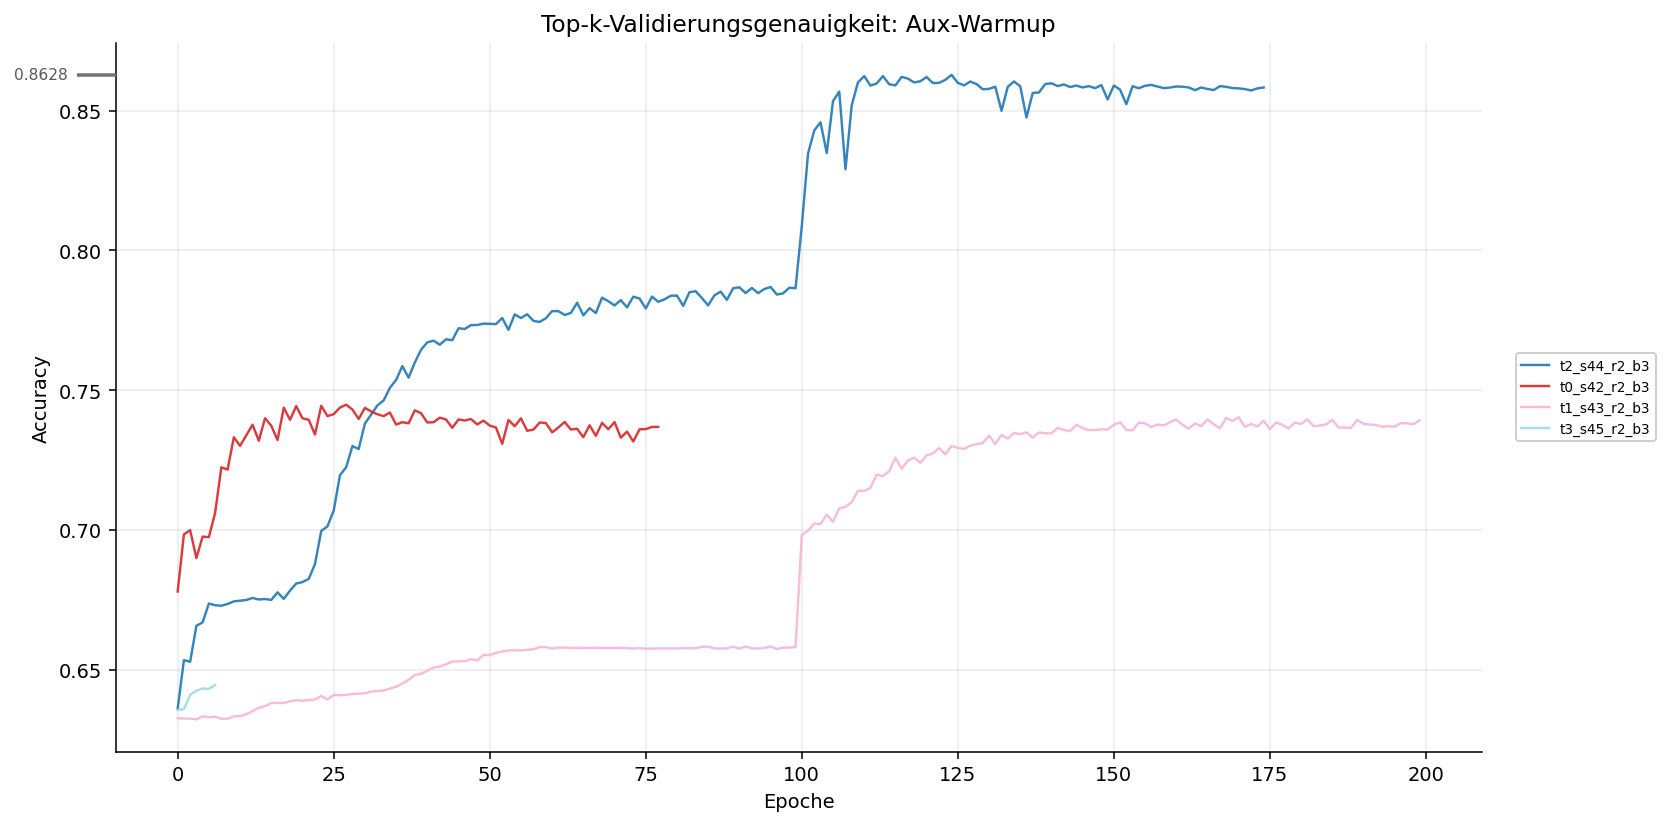

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_aux_warmup_train_val_hard_accuracy.png


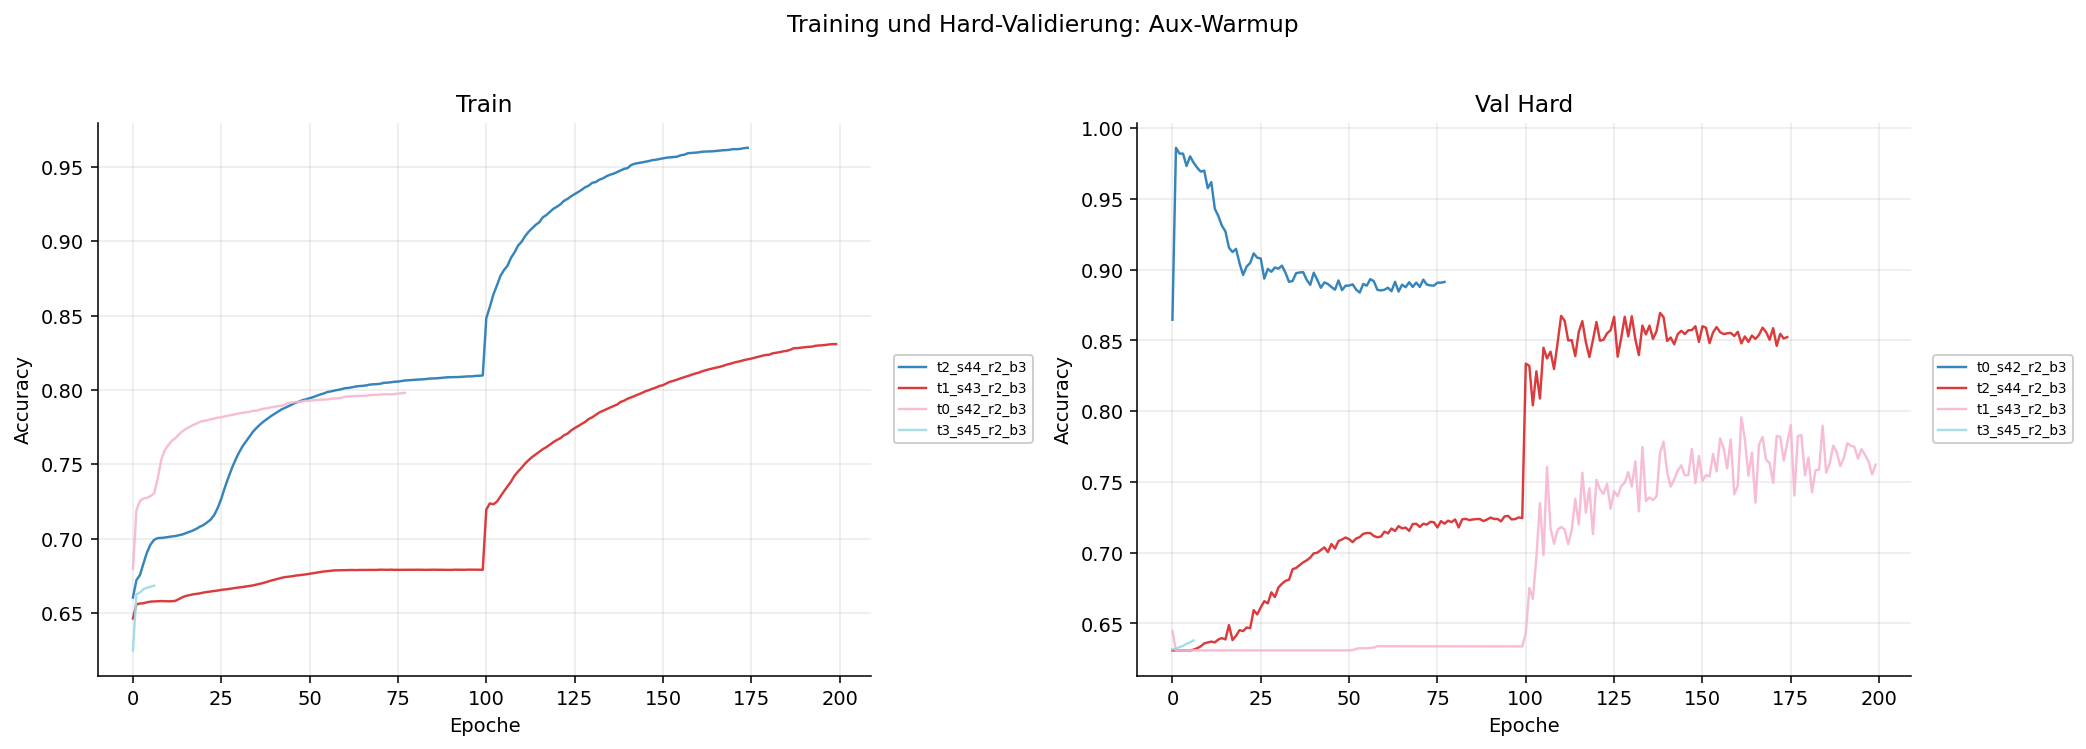

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_aux_warmup_val_hard_usage.png


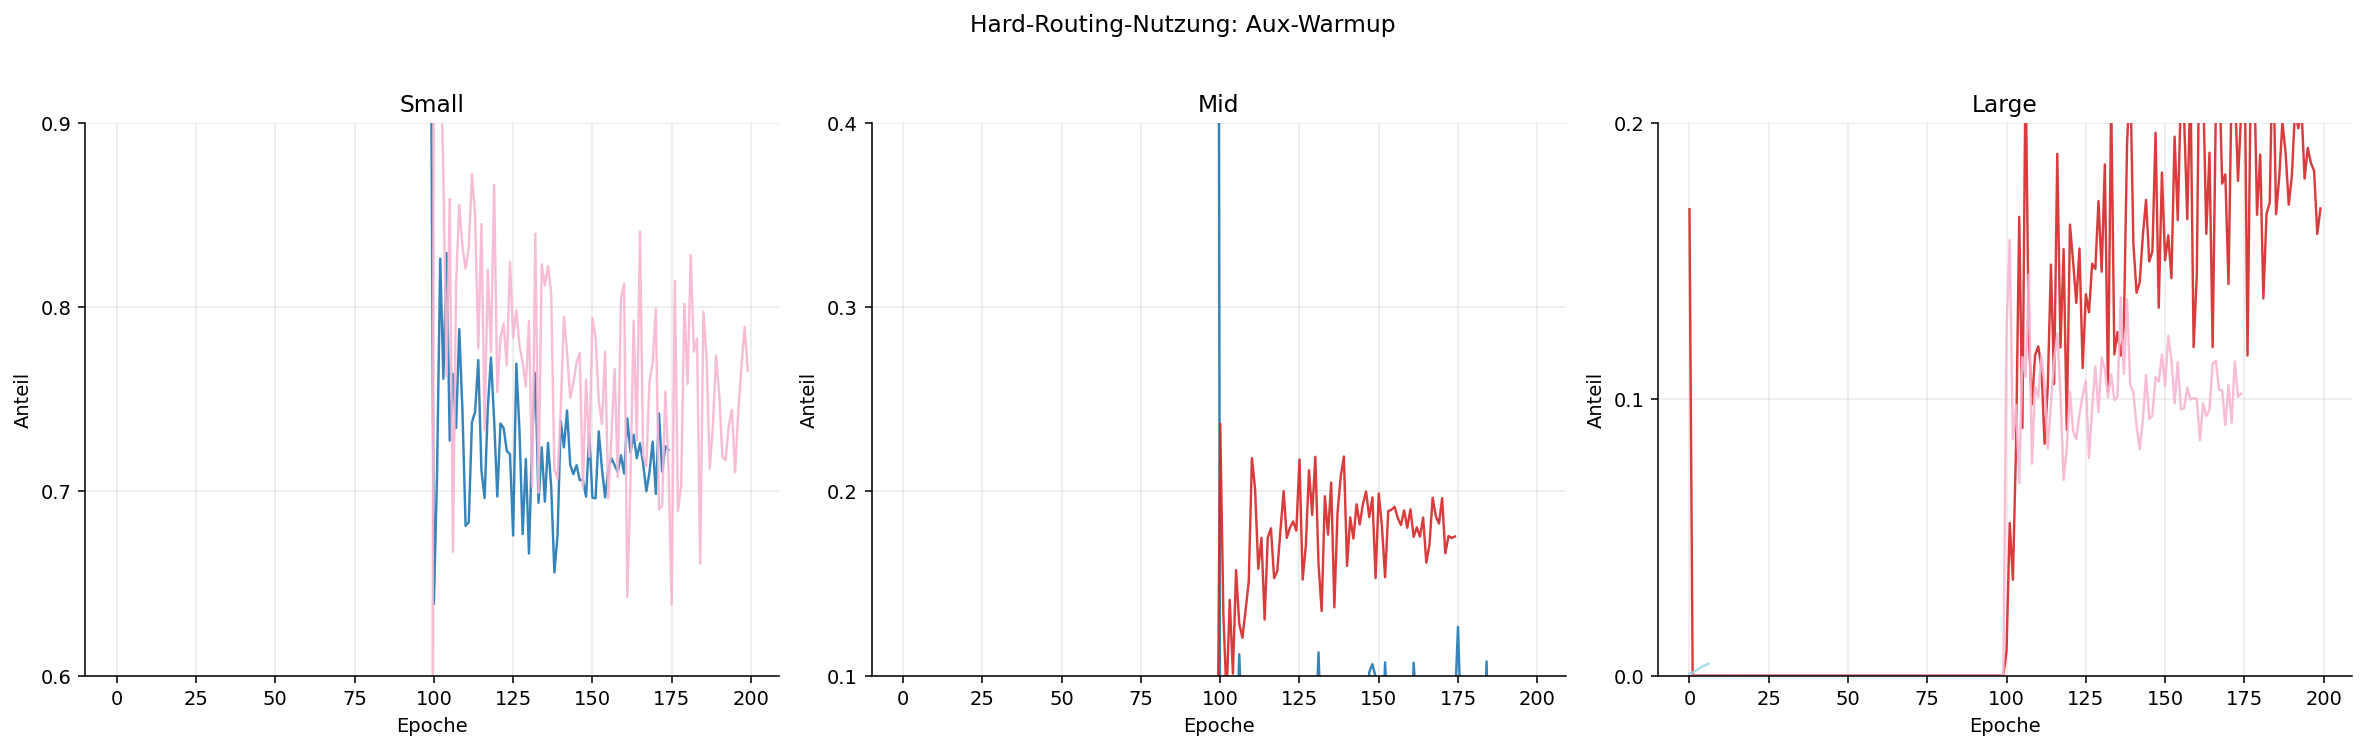

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_aux_warmup_val_expert_accuracy.png
/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_val_expert_accuracy_aux_warmup.png


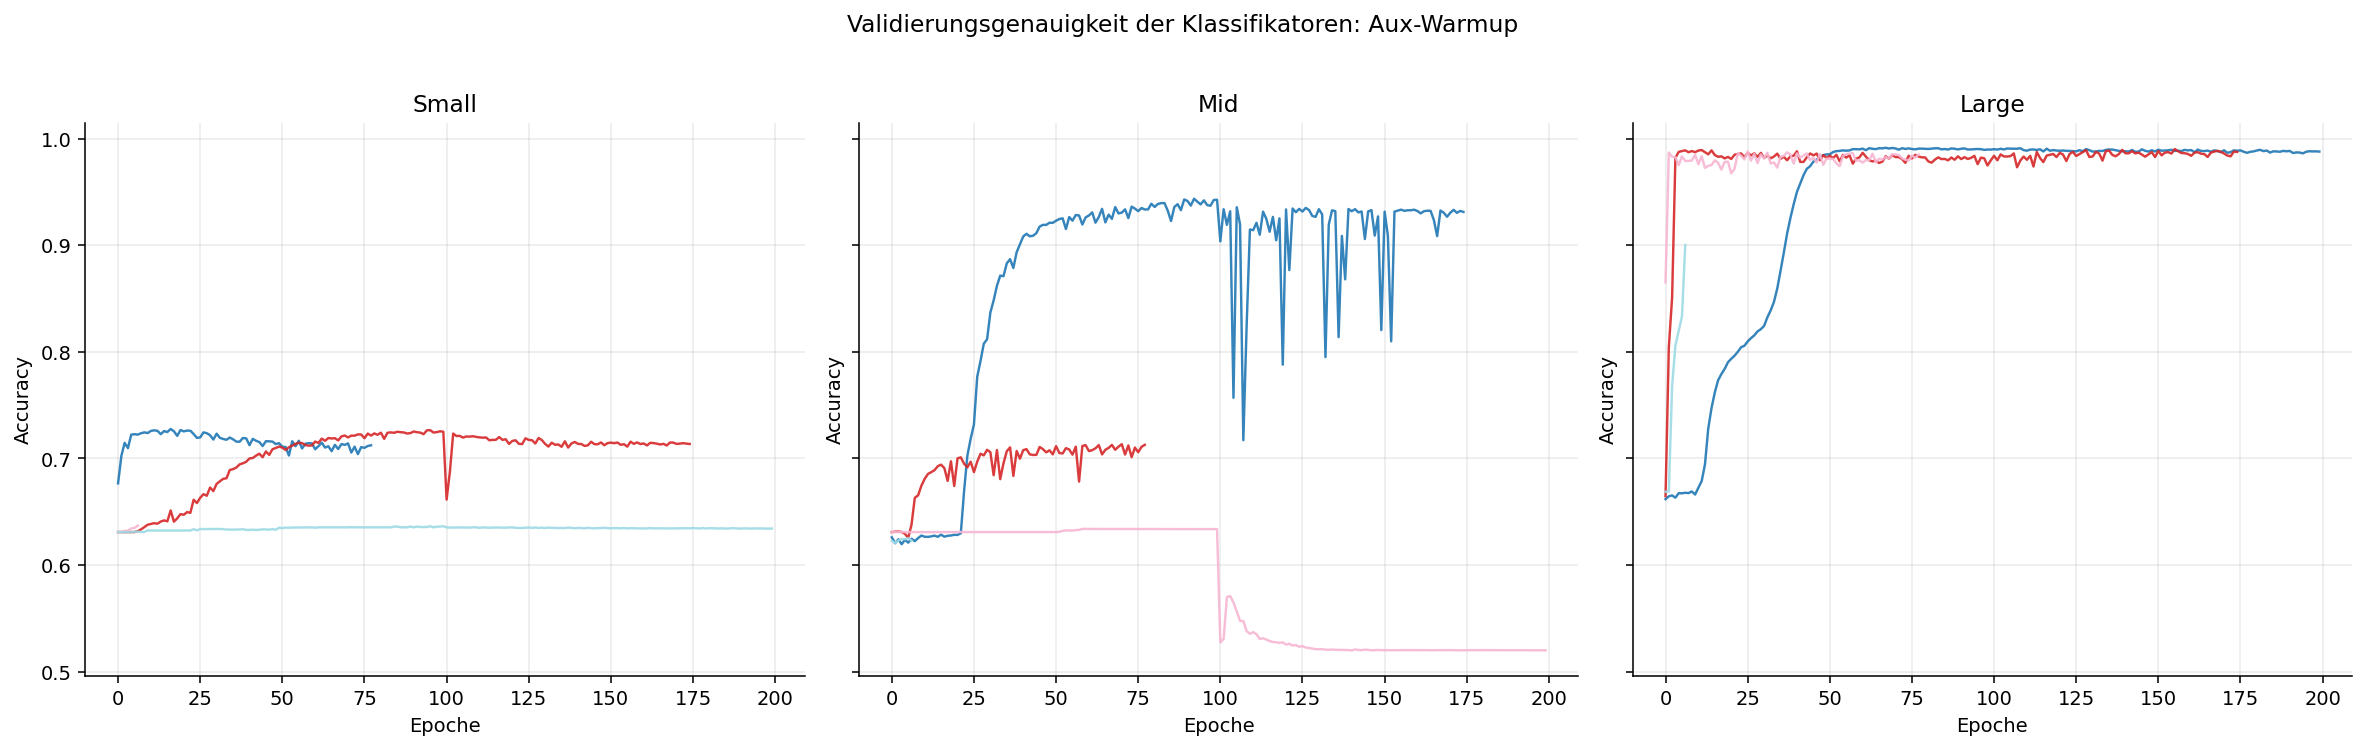

In [ ]:
variant = "Aux-Warmup"
fig, ax = plt.subplots(figsize=(12, max(6.0, 0.22 * len(run_order_for_variant(variant)))))
plot_runs(ax, variant, "val_topk/accuracy", "Accuracy", "Top-k-Validierungsgenauigkeit: Aux-Warmup", markiere_topk_maximum=True)
fig.tight_layout()
speichere_abbildung(fig, "big_randomsearch_aux_warmup_val_topk_accuracy.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharex=True)
plot_runs(axes[0], variant, "train/accuracy", "Accuracy", "Train")
plot_runs(axes[1], variant, "val_hard/accuracy", "Accuracy", "Val Hard")
fig.suptitle("Training und Hard-Validierung: Aux-Warmup", y=1.02)
fig.tight_layout()
speichere_abbildung(fig, "big_randomsearch_aux_warmup_train_val_hard_accuracy.png")
plt.show()

plot_usage(variant)
plot_runs_three_experts(variant)


## Pretrained


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_pretrained_val_topk_accuracy.png


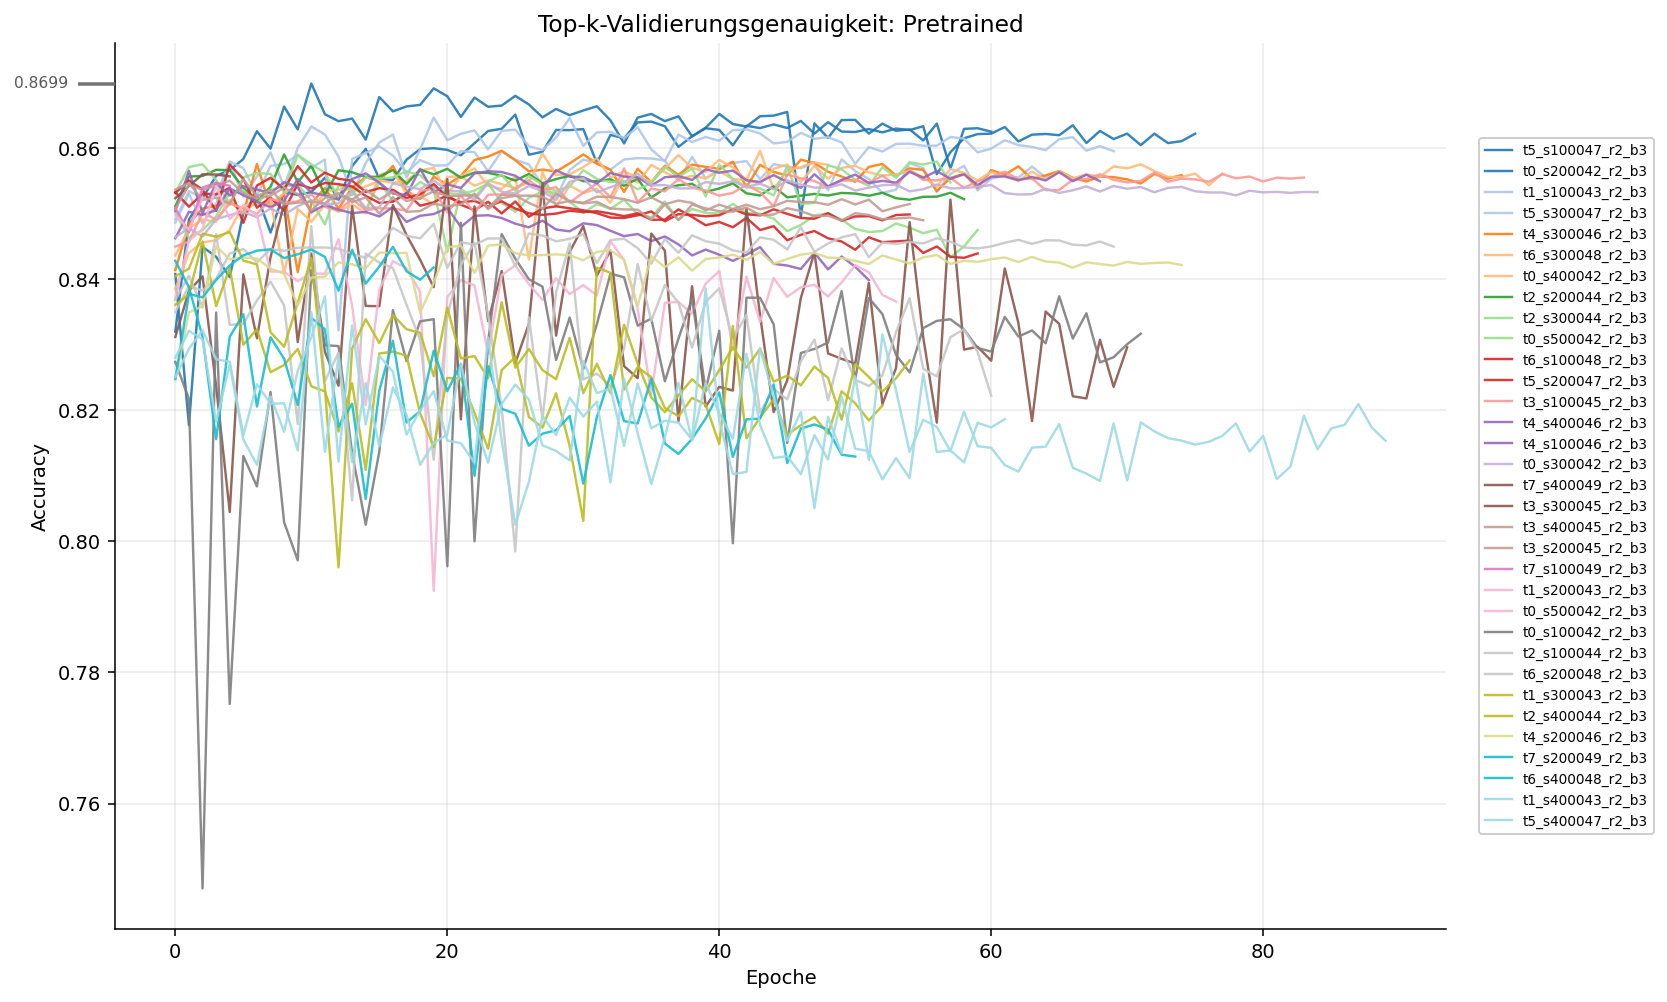

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_pretrained_train_val_hard_accuracy.png


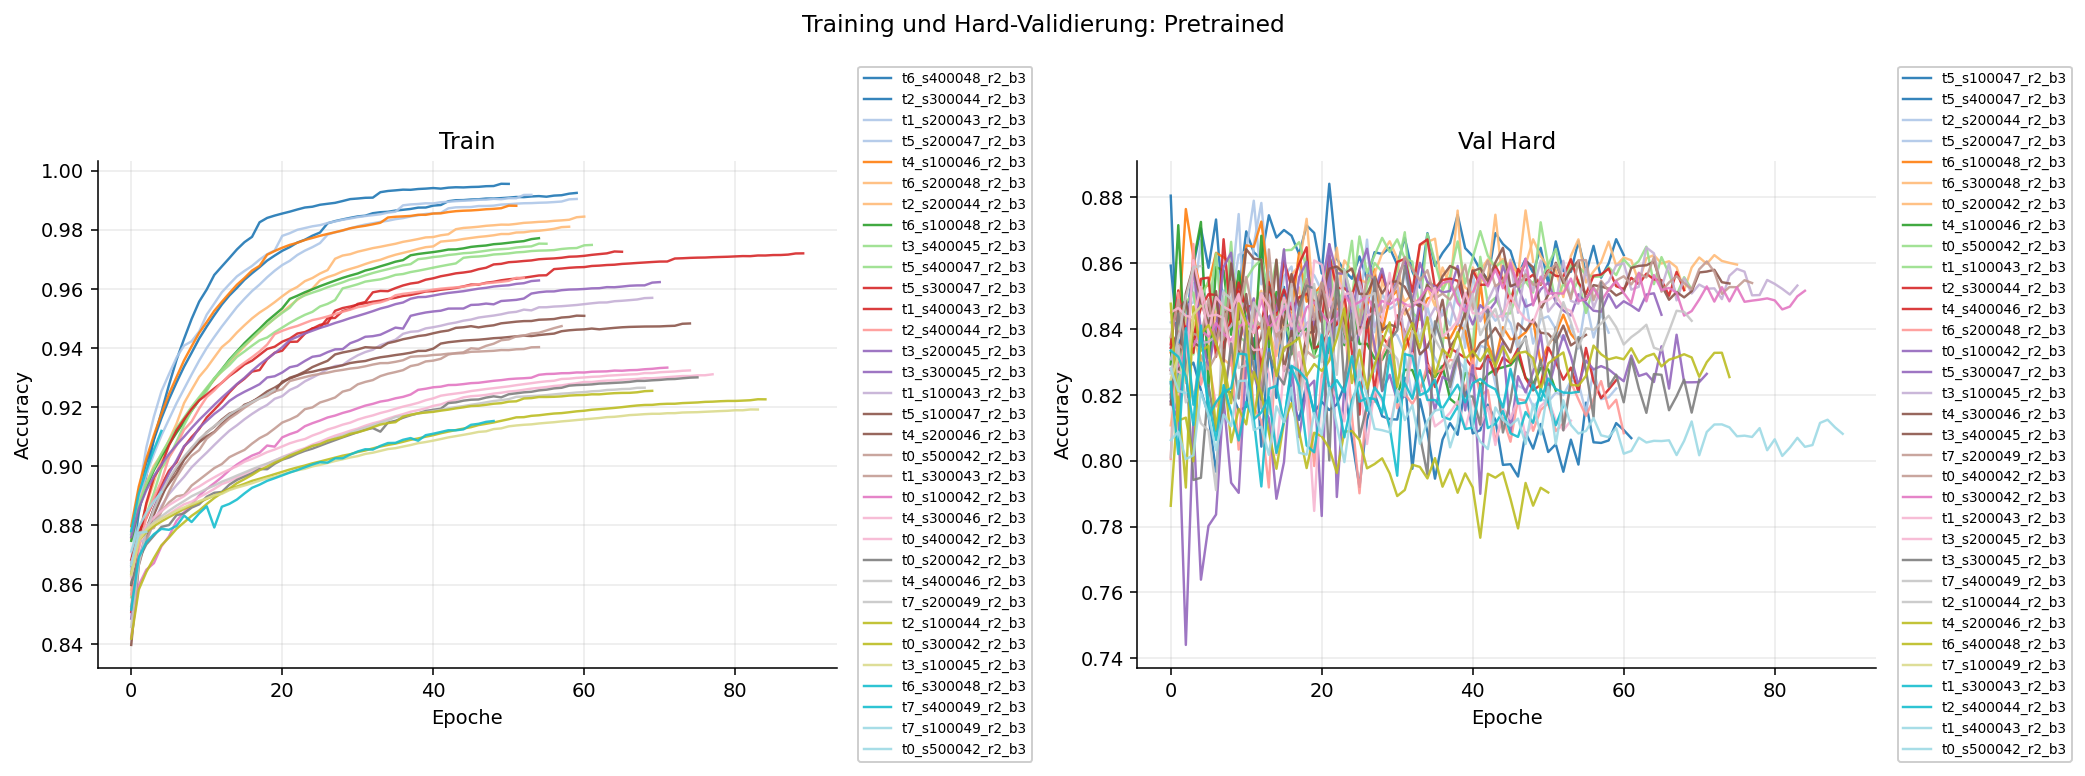

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_pretrained_val_hard_usage.png


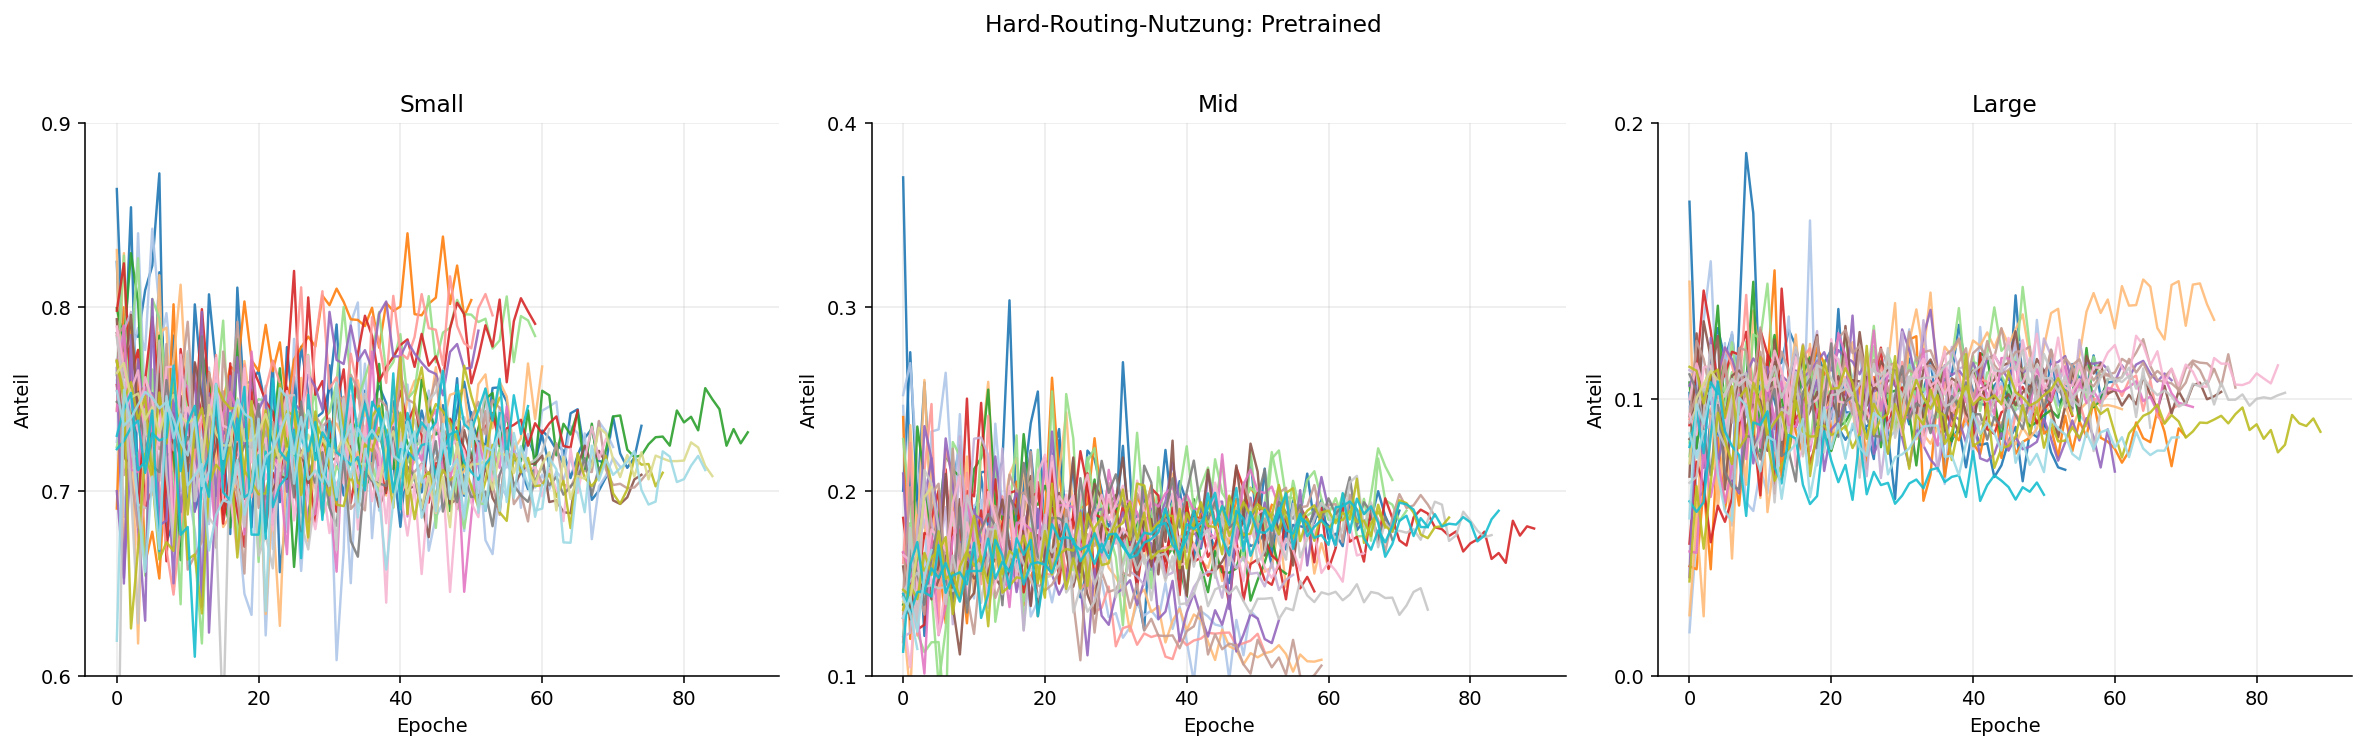

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_pretrained_val_expert_accuracy.png
/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_val_expert_accuracy_pretrained.png


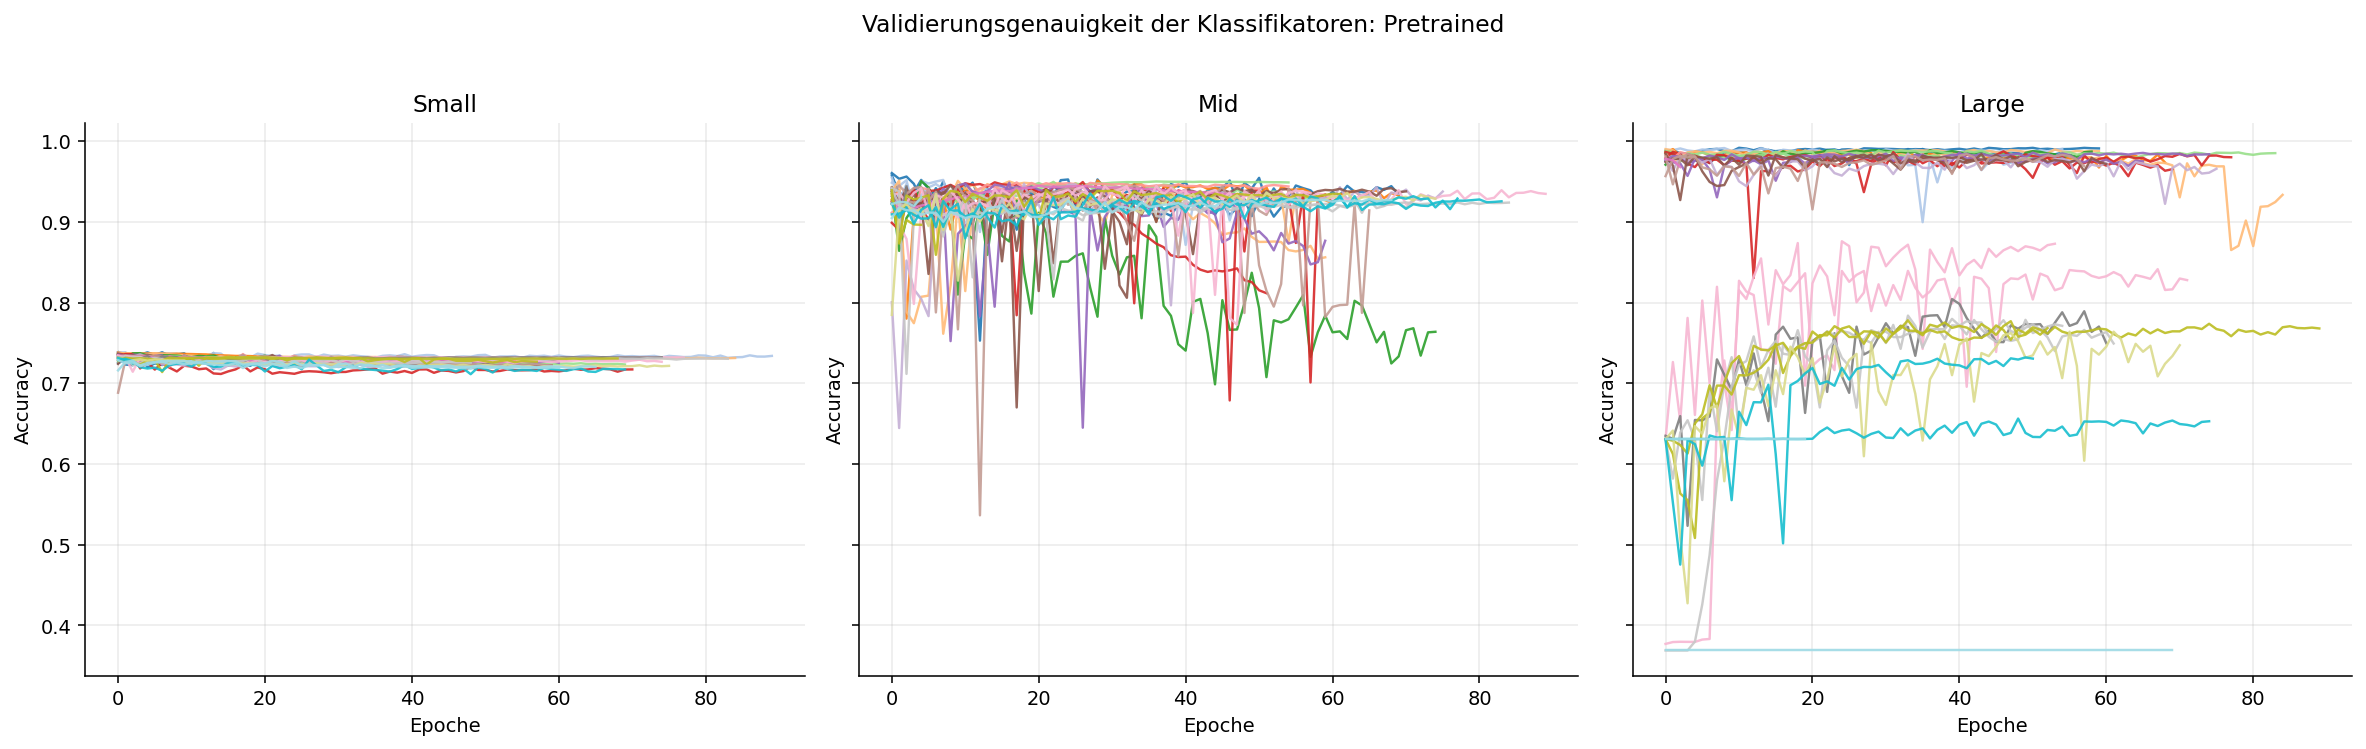

In [ ]:
variant = "Pretrained"
fig, ax = plt.subplots(figsize=(12, max(6.0, 0.22 * len(run_order_for_variant(variant)))))
plot_runs(ax, variant, "val_topk/accuracy", "Accuracy", "Top-k-Validierungsgenauigkeit: Pretrained", markiere_topk_maximum=True)
fig.tight_layout()
speichere_abbildung(fig, "big_randomsearch_pretrained_val_topk_accuracy.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharex=True)
plot_runs(axes[0], variant, "train/accuracy", "Accuracy", "Train")
plot_runs(axes[1], variant, "val_hard/accuracy", "Accuracy", "Val Hard")
fig.suptitle("Training und Hard-Validierung: Pretrained", y=1.02)
fig.tight_layout()
speichere_abbildung(fig, "big_randomsearch_pretrained_train_val_hard_accuracy.png")
plt.show()

plot_usage(variant)
plot_runs_three_experts(variant)


## Fully-Joint


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_fully_joint_val_topk_accuracy.png


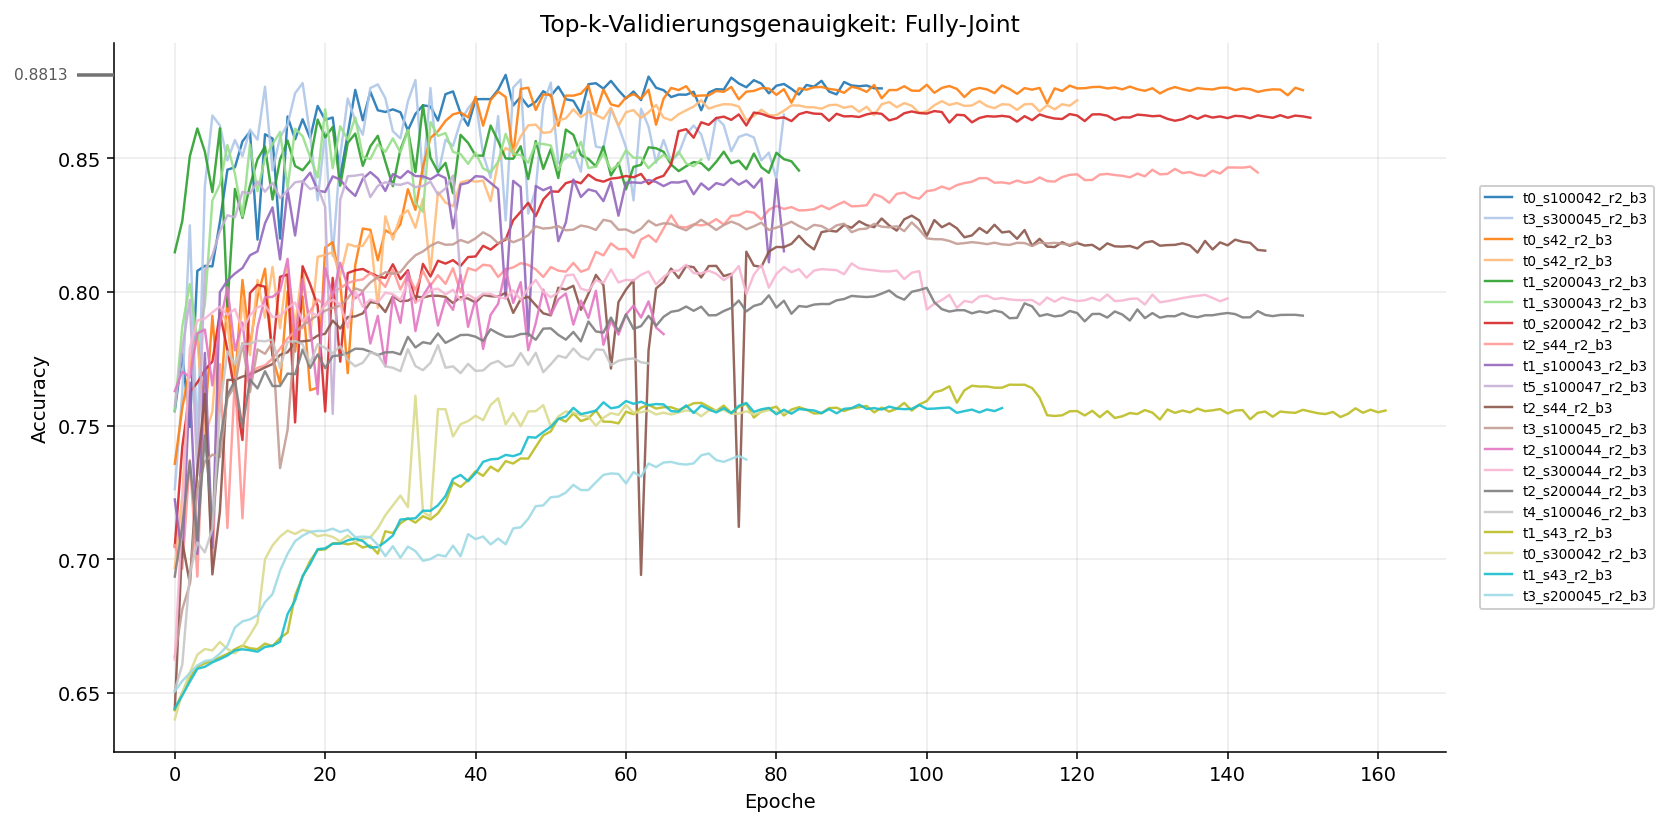

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_fully_joint_train_val_hard_accuracy.png


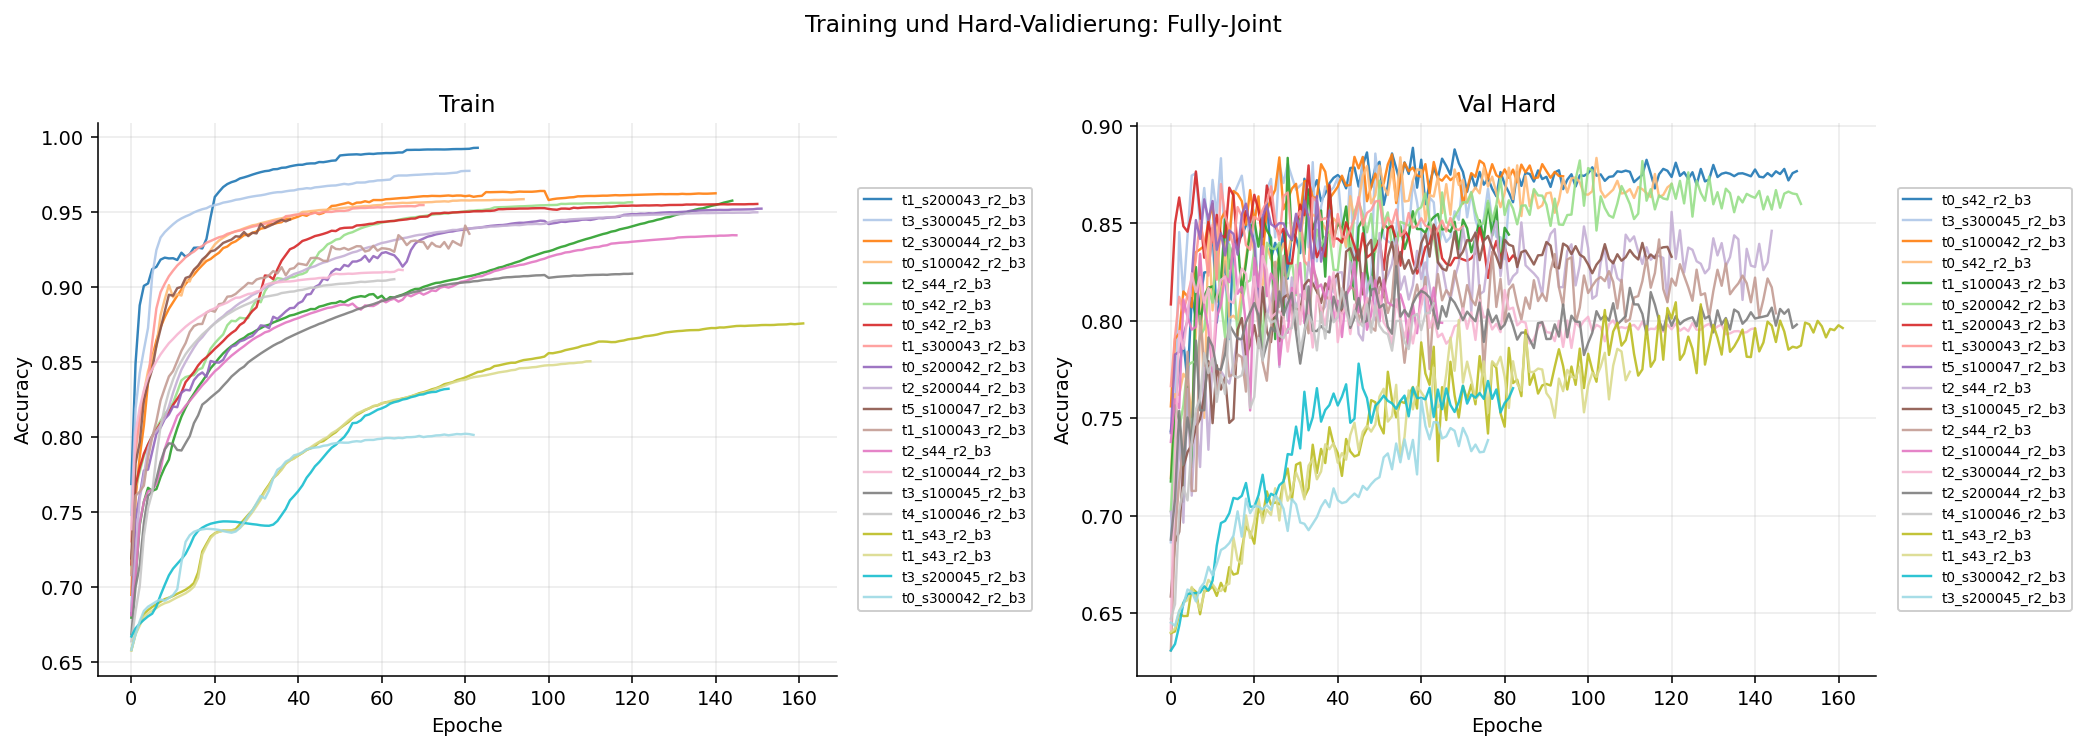

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_fully_joint_val_hard_usage.png


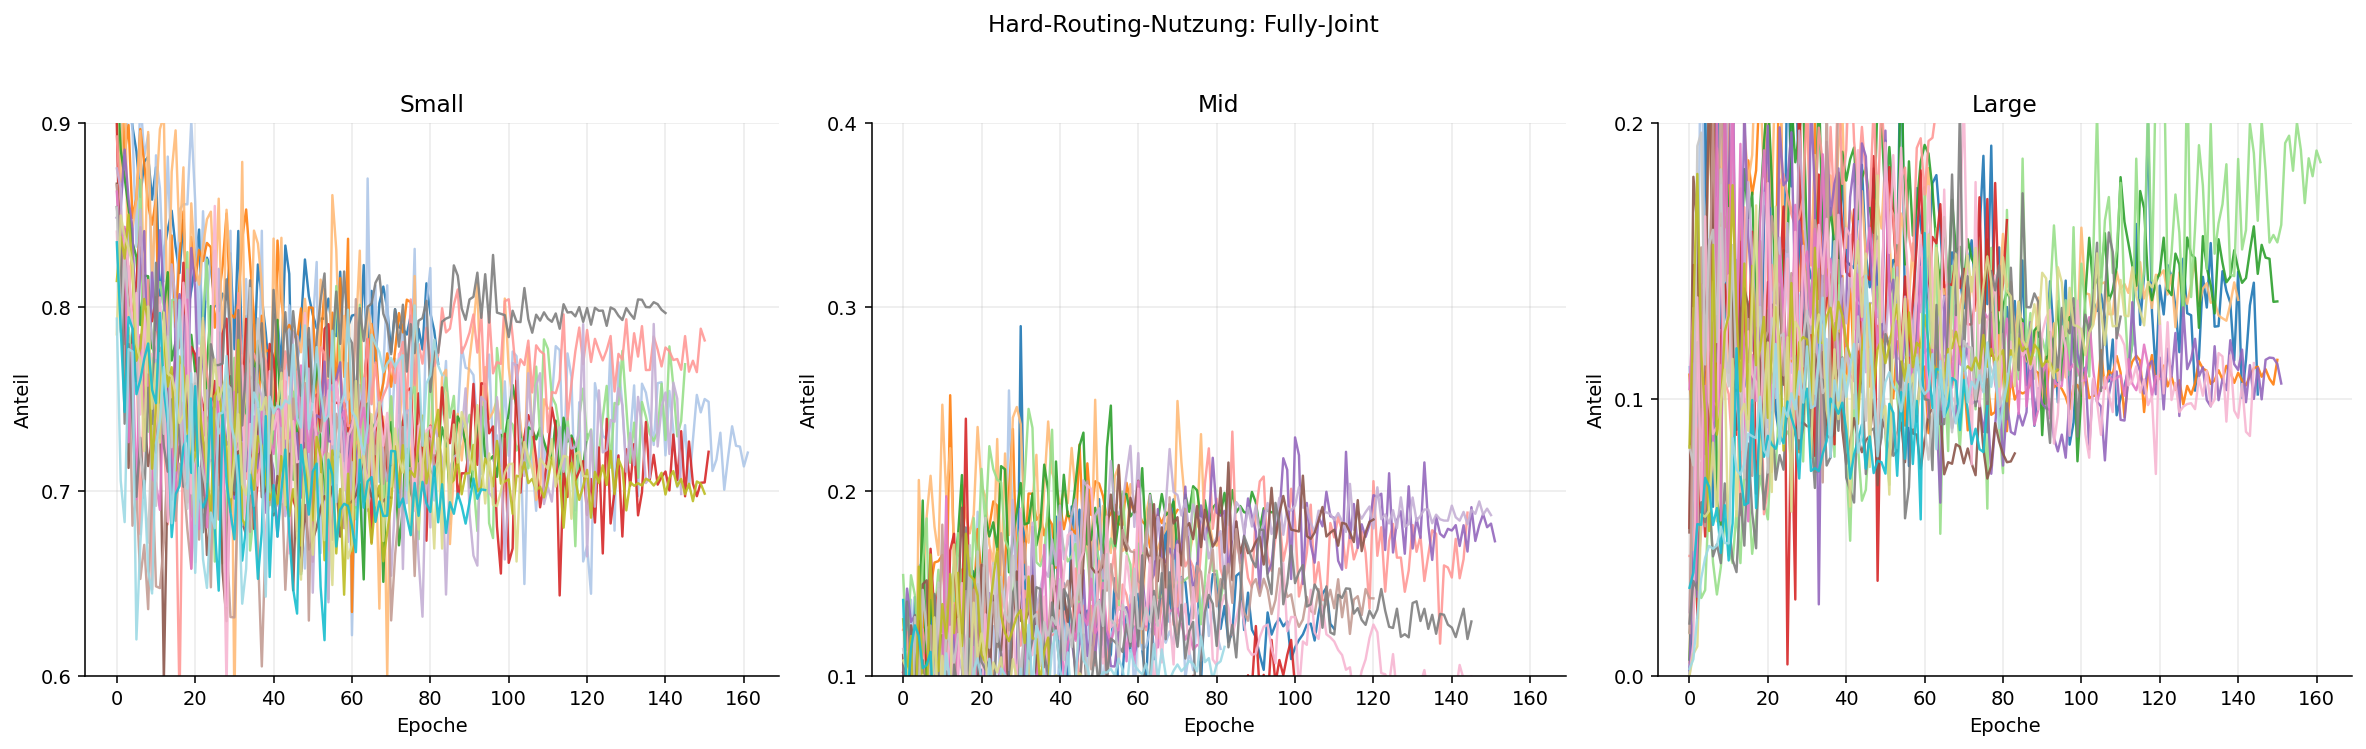

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_fully_joint_val_expert_accuracy.png
/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_val_expert_accuracy_fully_joint.png


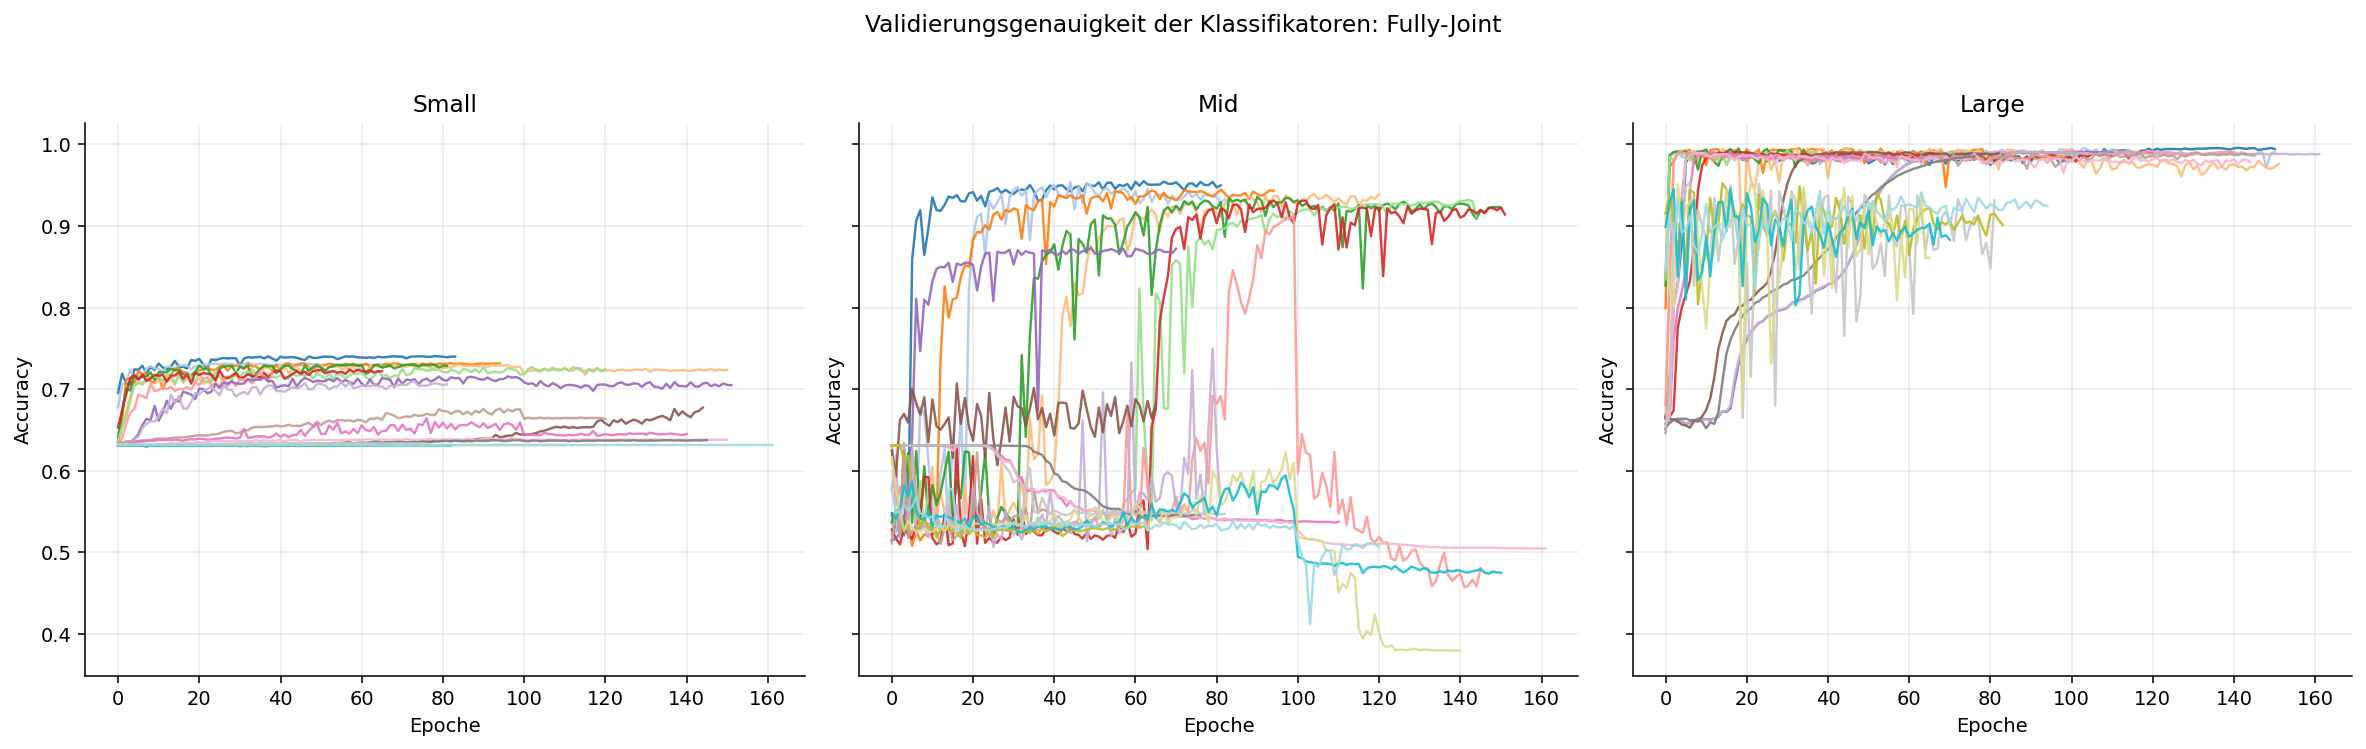

In [ ]:
variant = "Fully-Joint"
fig, ax = plt.subplots(figsize=(12, max(6.0, 0.22 * len(run_order_for_variant(variant)))))
plot_runs(ax, variant, "val_topk/accuracy", "Accuracy", "Top-k-Validierungsgenauigkeit: Fully-Joint", markiere_topk_maximum=True)
fig.tight_layout()
speichere_abbildung(fig, "big_randomsearch_fully_joint_val_topk_accuracy.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharex=True)
plot_runs(axes[0], variant, "train/accuracy", "Accuracy", "Train")
plot_runs(axes[1], variant, "val_hard/accuracy", "Accuracy", "Val Hard")
fig.suptitle("Training und Hard-Validierung: Fully-Joint", y=1.02)
fig.tight_layout()
speichere_abbildung(fig, "big_randomsearch_fully_joint_train_val_hard_accuracy.png")
plt.show()

plot_usage(variant)
plot_runs_three_experts(variant)


## Optionaler direkter Vergleich

Dieser Block ist nur zur groben Uebersicht. Die eigentliche Betrachtung oben bleibt nach Trainingstypen getrennt.


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_val_hard_usage.png


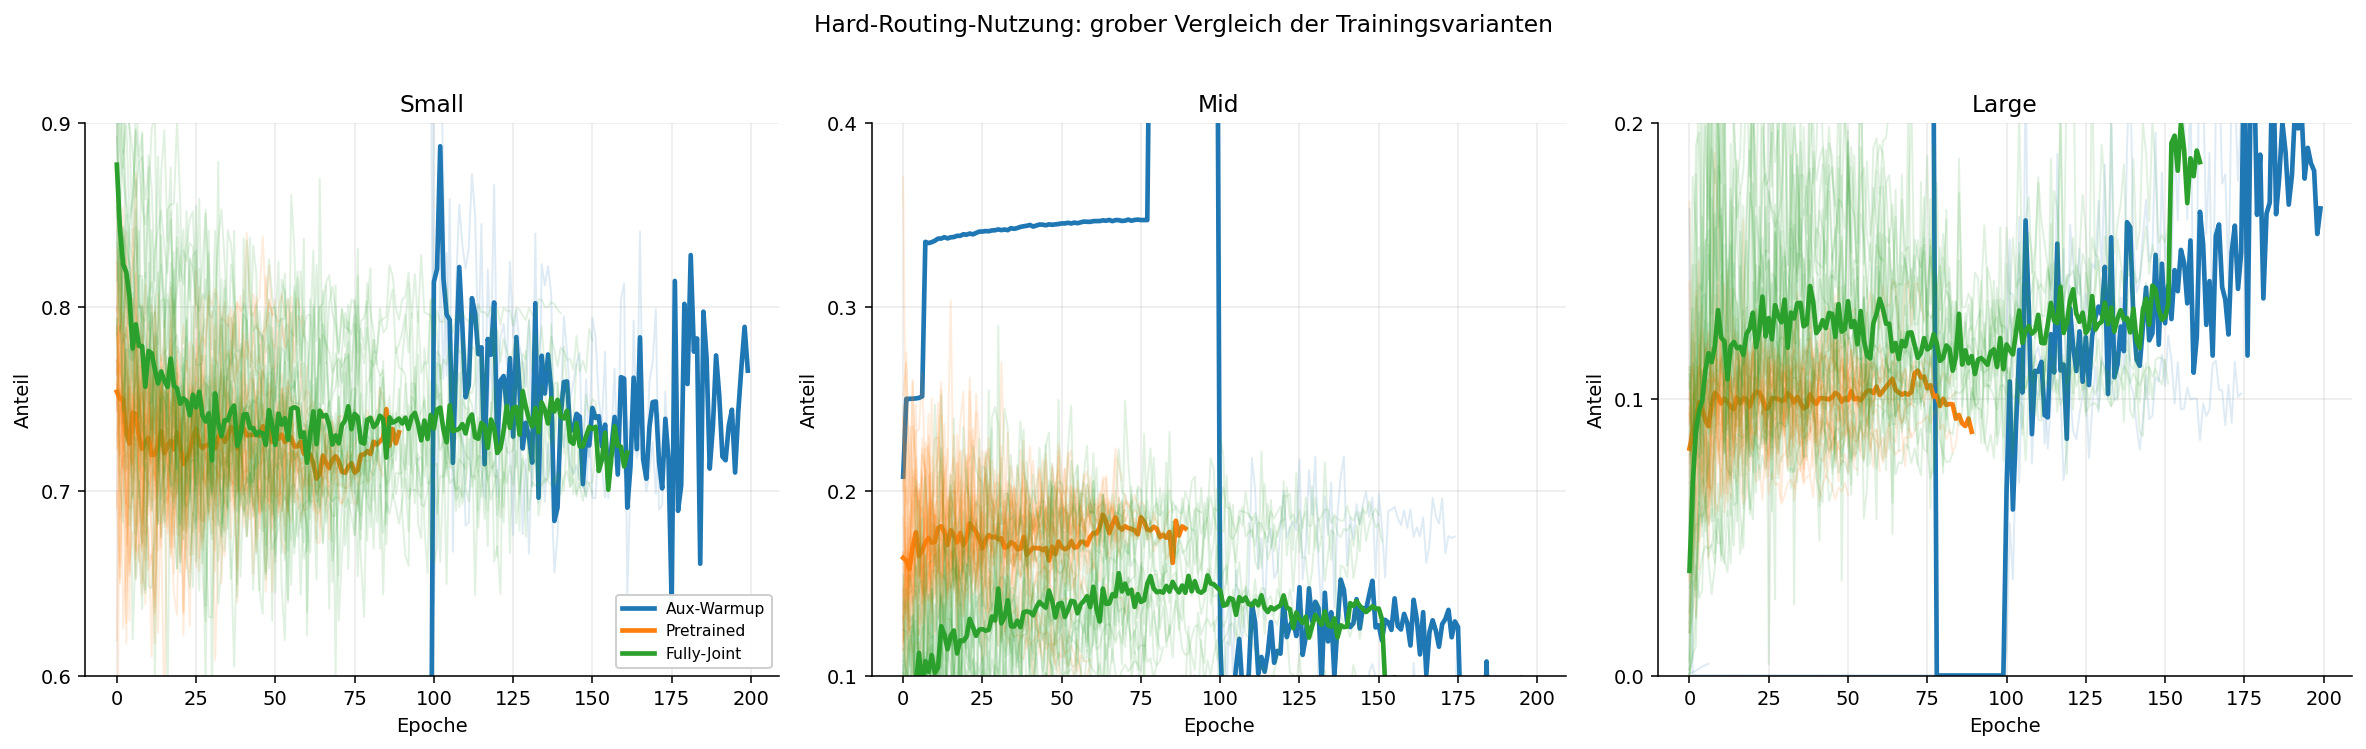

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_val_expert_accuracy_variants.png


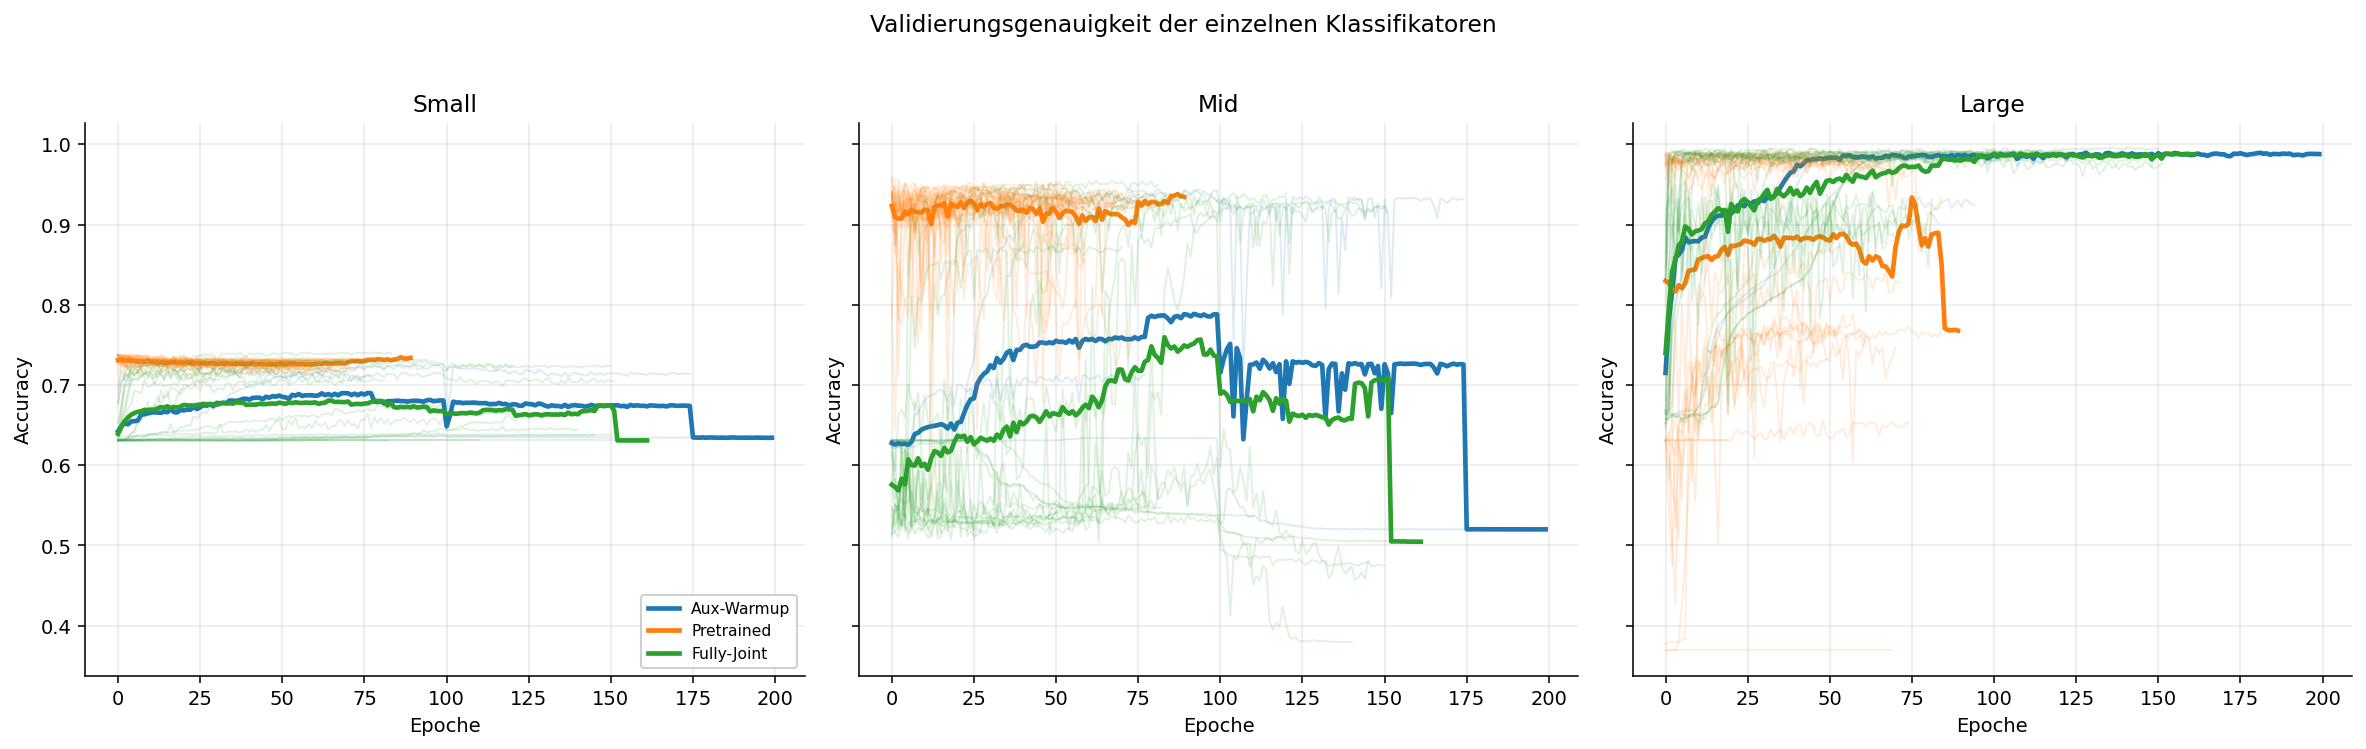

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_val_topk_accuracy_overview.png


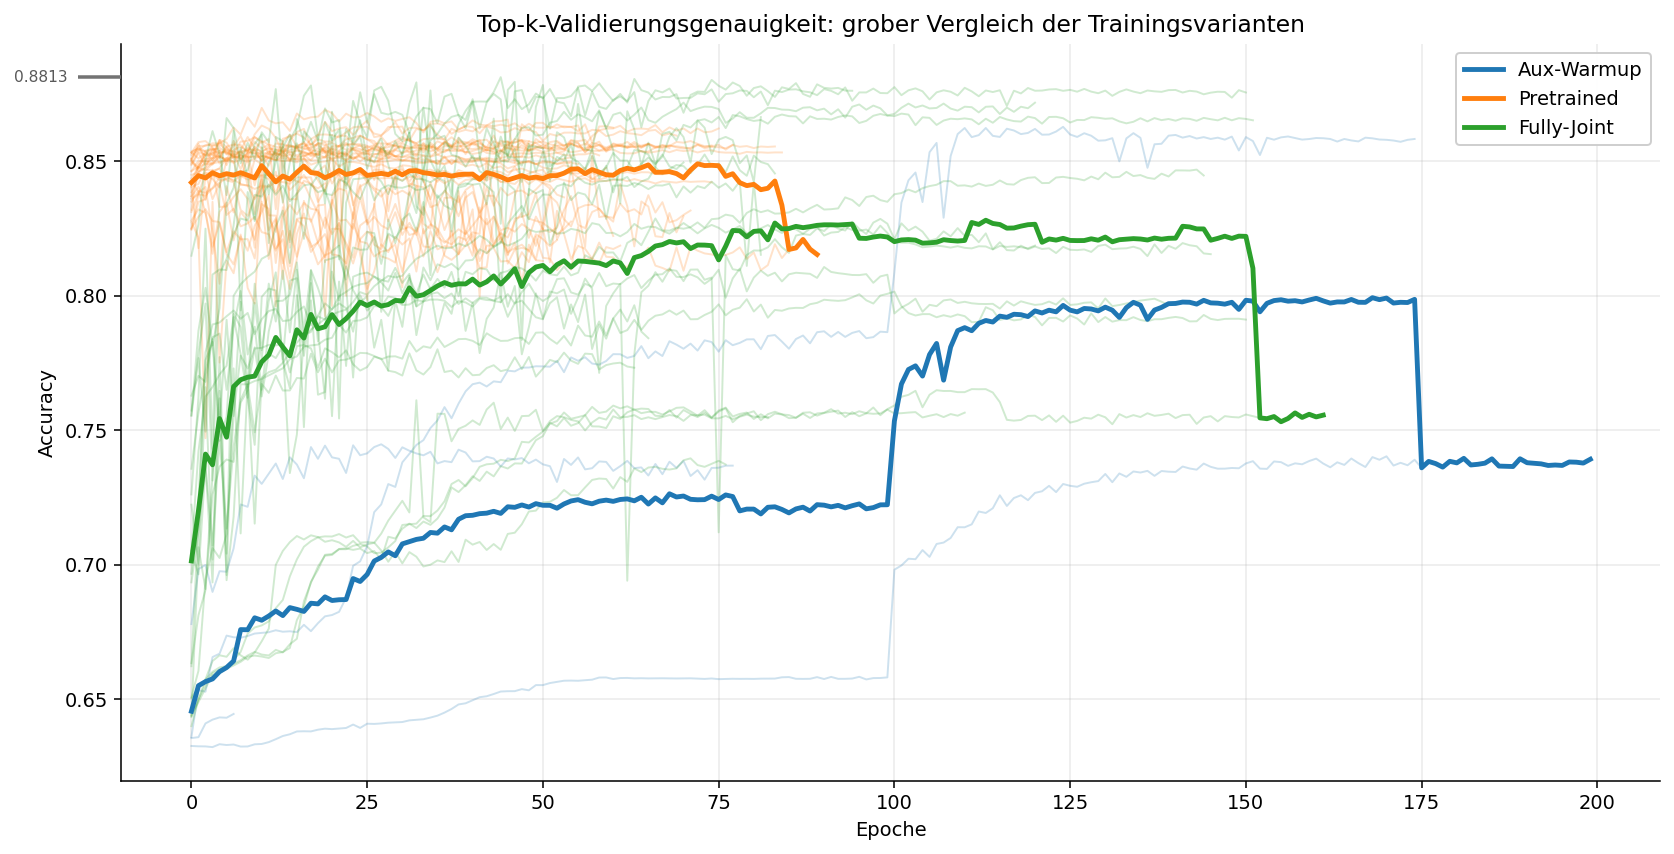

In [ ]:
plot_usage_variant_overview()
plot_expert_accuracy_variant_overview()

fig, ax = plt.subplots(figsize=(12, 6.2))
farben = {
    "Aux-Warmup": "tab:blue",
    "Pretrained": "tab:orange",
    "Fully-Joint": "tab:green",
}
for variant in [label for _, label in VARIANTEN]:
    frame = tag_frame("val_topk/accuracy", variant)
    for _, run_frame in frame.groupby("run"):
        run_frame = run_frame.sort_values("step")
        ax.plot(run_frame["step"], run_frame["value"], color=farben[variant], alpha=0.22, linewidth=1.0)

for variant in [label for _, label in VARIANTEN]:
    frame = tag_frame("val_topk/accuracy", variant)
    mean_frame = frame.groupby("step", as_index=False)["value"].mean()
    if not mean_frame.empty:
        ax.plot(mean_frame["step"], mean_frame["value"], color=farben[variant], linewidth=2.5, label=variant)

markiere_max_topk_validierungsgenauigkeit(ax, tag_frame("val_topk/accuracy"))

ax.set_title("Top-k-Validierungsgenauigkeit: grober Vergleich der Trainingsvarianten")
ax.set_xlabel("Epoche")
ax.set_ylabel("Accuracy")
ax.legend()
fig.tight_layout()
speichere_abbildung(fig, "big_randomsearch_val_topk_accuracy_overview.png")
plt.show()
